# 🧠 Kairos — Temporal Feature Fusion
### Regime-Aware Financial Trend Classification
**1D-CNN + Self-Attention  |  S&P 500  |  Anchored Walk-Forward Validation**

**Team:** Kanishk Srivastava · Raghav Sharma · Sayani Chanda

---
**BEFORE RUNNING:** `Runtime → Change runtime type → T4 GPU`

**Run cells in order — each cell depends on the previous.**

| Cell | Content |
|---|---|
| 1 | GPU check + install packages |
| 2 | All imports + seeds |
| 3 | Data download + 7-feature engineering |
| 4 | λ grid search + regime-aware labeling |
| 5 | Sequence builder → (N, C, T) |
| 6 | Anchored walk-forward splitter + per-fold normalization |
| 7 | Model definitions (Proposed, CNN, LSTM, XGBoost, Dummy) |
| 8 | Training loop (Focal Loss + AdamW + Cosine Annealing) |
| 9 | Results table + regime analysis |
| 10 | Visualizations (confusion matrices, fold plots, bar charts) |
| 11 | Attention weight visualization |
| 12 | Save to Google Drive (optional) |

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — GPU CHECK + PACKAGE INSTALL                          ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print('✅ GPU detected:', result.stdout.strip())
except Exception:
    print('⚠️  No GPU. Go to Runtime → Change runtime type → T4 GPU')
    print('   Training will work on CPU but will be much slower.')

print('\nInstalling packages...')
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'yfinance', 'ta', 'xgboost'],
    check=True
)
print('✅ All packages installed.')


✅ GPU detected: Tesla T4, 15360 MiB

Installing packages...
✅ All packages installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — ALL IMPORTS                                          ║
# ╚══════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    f1_score, matthews_corrcoef, accuracy_score,
    confusion_matrix, recall_score
)
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports complete.  Device: {DEVICE}')


✅ Imports complete.  Device: cuda


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — DATA DOWNLOAD + FEATURE ENGINEERING (C = 7)         ║
# ╚══════════════════════════════════════════════════════════════════╝
# All features are derived from PAST data only — zero lookahead.
# Raw price levels never fed to model (stationarity enforced).

TICKER     = '^GSPC'
START_DATE = '2013-01-01'
END_DATE   = '2023-12-31'
LOOKBACK   = 20
HORIZON    = 5
VOL_WINDOW = 30
N_FOLDS    = 3
TEST_RATIO = 0.12

print(f'Downloading {TICKER} ({START_DATE} to {END_DATE})...')
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)
raw = raw.dropna()
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
print(f'✅ Downloaded {len(raw)} trading days.')

feat  = pd.DataFrame(index=raw.index)
close = raw['Close']
open_ = raw['Open']
high  = raw['High']
low   = raw['Low']

# 1-4: OHLC log-returns (stationary by construction)
feat['log_ret_close'] = np.log(close / close.shift(1))
feat['log_ret_open']  = np.log(open_  / open_.shift(1))
feat['log_ret_high']  = np.log(high   / high.shift(1))
feat['log_ret_low']   = np.log(low    / low.shift(1))

# 5: 20-day rolling realized volatility
feat['rolling_vol_20'] = (
    feat['log_ret_close'].rolling(window=20, min_periods=20).std()
)

# 6: RSI-14 normalized to [0,1]
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_g = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    avg_l = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rs    = avg_g / (avg_l + 1e-10)
    return (100 - 100 / (1 + rs)) / 100.0

feat['rsi_14'] = compute_rsi(close)

# 7: MACD signal normalized by price (stationary)
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()
feat['macd_norm'] = (ema12 - ema26) / close

feat = feat.dropna()
print(f'✅ Features computed. Shape: {feat.shape}  '
      f'(dropped {len(raw) - len(feat)} warm-up rows)')
print(f'   Columns: {list(feat.columns)}')
feat.tail(3)


✅ Downloaded 2768 trading days.
✅ Features computed. Shape: (2748, 7)  (dropped 20 warm-up rows)
   Columns: ['log_ret_close', 'log_ret_open', 'log_ret_high', 'log_ret_low', 'rolling_vol_20', 'rsi_14', 'macd_norm']


,log_ret_close,log_ret_open,log_ret_high,log_ret_low,rolling_vol_20,rsi_14,macd_norm
Date,,,,,,,
2023-12-27,0.001429,0.003061,0.000140,0.002194,0.006003,0.732569,0.016310
2023-12-28,0.000370,0.002718,0.001652,0.002530,0.005971,0.734071,0.016175
2023-12-29,-0.002830,-0.000744,-0.001016,-0.006082,0.006078,0.701649,0.015709


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — λ GRID SEARCH + REGIME-AWARE LABELING               ║
# ╚══════════════════════════════════════════════════════════════════╝

def generate_labels(raw_df, feature_index, lambda_val, k=5, vol_window=30):
    # Dynamic Volatility Barrier labeling.
    # R_t = log(Close_{t+k}/Close_t)  [forward return, label only]
    # eps = lambda * rolling_std(past log-returns)  [past data only]
    # Down(0): R_t < -eps  | Neutral(1): |R_t|<=eps | Up(2): R_t > eps
    close = raw_df['Close']
    if isinstance(close, pd.DataFrame):
        close = close.squeeze()
    R_t      = np.log(close.shift(-k) / close)
    past_ret = np.log(close / close.shift(1))
    sigma_t  = past_ret.rolling(window=vol_window, min_periods=vol_window).std()
    epsilon  = lambda_val * sigma_t
    labels   = pd.Series(np.nan, index=close.index)
    labels[R_t >  epsilon]  = 2
    labels[R_t < -epsilon]  = 0
    labels[(R_t >= -epsilon) & (R_t <= epsilon)] = 1
    return labels.reindex(feature_index)


def class_distribution(labels):
    valid  = labels.dropna()
    counts = valid.value_counts().sort_index()
    total  = len(valid)
    return {
        'Down (0)':    round(counts.get(0, 0) / total * 100, 1),
        'Neutral (1)': round(counts.get(1, 0) / total * 100, 1),
        'Up (2)':      round(counts.get(2, 0) / total * 100, 1),
    }


n_search   = int(len(feat) * 0.60)
search_idx = feat.index[:n_search]
LAMBDA_CANDIDATES = [0.5, 1.0, 1.5]
TARGET_MID = 42.5

print('=' * 55)
print('  lambda GRID SEARCH  (training data only)')
print('=' * 55)

best_lambda, best_score = None, float('inf')
for lam in LAMBDA_CANDIDATES:
    lbl  = generate_labels(raw, search_idx, lam, HORIZON, VOL_WINDOW)
    dist = class_distribution(lbl)
    neutral_pct = dist['Neutral (1)']
    print(f'\n  lambda = {lam}')
    for cls, pct in dist.items():
        bar = chr(9608) * int(pct / 2)
        print(f'    {cls}: {pct:5.1f}%  {bar}')
    score = abs(neutral_pct - TARGET_MID)
    if score < best_score:
        best_score, best_lambda = score, lam

print(f'\n  SELECTED lambda = {best_lambda}')
print('=' * 55)

LAMBDA     = best_lambda
all_labels = generate_labels(raw, feat.index, LAMBDA, HORIZON, VOL_WINDOW)
full_dist  = class_distribution(all_labels)
print(f'\nFull dataset class distribution (lambda={LAMBDA}):')
for cls, pct in full_dist.items():
    print(f'  {cls}: {pct}%')


  lambda GRID SEARCH  (training data only)

  lambda = 0.5
    Down (0):  30.7%  ███████████████
    Neutral (1):  19.0%  █████████
    Up (2):  50.3%  █████████████████████████

  lambda = 1.0
    Down (0):  23.8%  ███████████
    Neutral (1):  37.3%  ██████████████████
    Up (2):  38.9%  ███████████████████

  lambda = 1.5
    Down (0):  18.3%  █████████
    Neutral (1):  53.2%  ██████████████████████████
    Up (2):  28.5%  ██████████████

  SELECTED lambda = 1.0

Full dataset class distribution (lambda=1.0):
  Down (0): 24.0%
  Neutral (1): 36.4%
  Up (2): 39.6%


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — SEQUENCE BUILDER                                     ║
# ╚══════════════════════════════════════════════════════════════════╝

def build_sequences(features_df, labels_series, lookback=20):
    # Sliding-window sequences.
    # Output: X(N,C,T), y(N,), dates(N,)
    feat_arr  = features_df.values
    label_arr = labels_series.values
    date_arr  = features_df.index.values
    X_list, y_list, d_list = [], [], []
    for i in range(lookback, len(feat_arr)):
        lbl = label_arr[i]
        if np.isnan(lbl):
            continue
        window = feat_arr[i - lookback : i]   # (T, C)
        X_list.append(window.T)               # (C, T) for Conv1d
        y_list.append(int(lbl))
        d_list.append(date_arr[i])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list,  dtype=np.int64)
    d = np.array(d_list)
    print(f'Sequences built: X={X.shape}, y={y.shape}')
    print(f'Class counts -- Down={np.sum(y==0)}, '
          f'Neutral={np.sum(y==1)}, Up={np.sum(y==2)}')
    return X, y, d


X_all, y_all, dates_all = build_sequences(feat, all_labels, LOOKBACK)


Sequences built: X=(2723, 7, 20), y=(2723,)
Class counts -- Down=654, Neutral=991, Up=1078


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — ANCHORED WALK-FORWARD SPLITTER + NORMALIZATION       ║
# ╚══════════════════════════════════════════════════════════════════╝
# Training window GROWS with each fold (anchored = always starts 2013).
# Z-score normalization fitted on TRAINING fold only — no leakage.

def normalize_fold(X_train, X_test):
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True)
    std  = np.where(std < 1e-8, 1e-8, std)
    return (X_train - mean) / std, (X_test - mean) / std


def make_folds(X, y, dates, n_folds=3, test_ratio=0.12):
    N         = len(X)
    test_size = int(N * test_ratio)
    train_end0 = N - n_folds * test_size
    print('=' * 62)
    print(f'  WALK-FORWARD SPLIT  ({n_folds} folds, test_size={test_size})')
    print('=' * 62)
    folds = []
    for fid in range(1, n_folds + 1):
        ts = train_end0 + (fid - 1) * test_size
        te = ts + test_size
        X_tr_raw, y_tr = X[:ts], y[:ts]
        X_te_raw, y_te = X[ts:te], y[ts:te]
        d_tr, d_te     = dates[:ts], dates[ts:te]
        X_tr, X_te = normalize_fold(X_tr_raw, X_te_raw)
        vol       = X_te_raw[:, 4, -1]
        med       = np.median(vol)
        lv_mask   = vol <= med
        hv_mask   = vol >  med
        reg_valid = (lv_mask.sum() >= 50 and hv_mask.sum() >= 50)
        folds.append({
            'fold_id':      fid,
            'X_train':      X_tr,     'y_train': y_tr,
            'X_test':       X_te,     'y_test':  y_te,
            'X_train_raw':  X_tr_raw, 'X_test_raw': X_te_raw,
            'dates_train':  d_tr,     'dates_test':  d_te,
            'low_vol_mask': lv_mask,  'high_vol_mask': hv_mask,
            'regime_valid': reg_valid,
        })
        print(f'  Fold {fid}: Train {pd.Timestamp(d_tr[0]).date()}->'
              f'{pd.Timestamp(d_tr[-1]).date()} ({len(y_tr)})  |  '
              f'Test {pd.Timestamp(d_te[0]).date()}->'
              f'{pd.Timestamp(d_te[-1]).date()} ({len(y_te)})')
        print(f'           Regime valid: {reg_valid}  '
              f'(low={lv_mask.sum()}, high={hv_mask.sum()})')
    print('=' * 62)
    return folds


FOLDS = make_folds(X_all, y_all, dates_all, N_FOLDS, TEST_RATIO)


  WALK-FORWARD SPLIT  (3 folds, test_size=326)
  Fold 1: Train 2013-03-01->2020-02-04 (1745)  |  Test 2020-02-05->2021-05-20 (326)
           Regime valid: True  (low=163, high=163)
  Fold 2: Train 2013-03-01->2021-05-20 (2071)  |  Test 2021-05-21->2022-09-06 (326)
           Regime valid: True  (low=163, high=163)
  Fold 3: Train 2013-03-01->2022-09-06 (2397)  |  Test 2022-09-07->2023-12-21 (326)
           Regime valid: True  (low=163, high=163)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — MODEL DEFINITIONS                                    ║
# ╚══════════════════════════════════════════════════════════════════╝
# Architecture: INPUT(C*T) -> Input-BN -> Residual-CNN -> Transformer -> HEAD
#
# Key improvements vs baseline:
#   * Residual blocks in CNN (prevents gradient vanishing, 3 layers)
#   * 4-head attention (was 2), 2 transformer layers (was 1)
#   * Input BatchNorm (stabilises heterogeneous feature scales)
#   * Concat(avg+max) global pooling (richer representation)
#   * GELU activations (smoother gradients than ReLU)
#   * Xavier/Kaiming init for stable training from epoch 1

C_FEAT = X_all.shape[1]   # 7


# ── Sinusoidal Positional Encoding ────────────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# ── Residual 1D-CNN Block ──────────────────────────────────────────────
class ResBlock1d(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(channels)
        self.drop  = nn.Dropout(dropout)
        self.act   = nn.GELU()

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return self.act(out + x)   # residual connection


# ── PROPOSED MODEL ─────────────────────────────────────────────────────
class ProposedModel(nn.Module):
    # Input  : (B, C, T)
    # Output : (B, 3)
    # Stage 1 -- InputBN + projection to cnn_ch channels
    # Stage 2 -- 3x Residual CNN blocks: local temporal pattern extraction
    # Stage 3 -- 2-layer Transformer Encoder (4 heads): long-range context
    # Stage 4 -- Concat(avg+max) pooling -> classification head
    def __init__(self, C=7, T=20, cnn_ch=128, n_heads=4,
                 ffn_dim=256, dropout=0.2, n_classes=3):
        super().__init__()
        self.input_bn   = nn.BatchNorm1d(C)
        self.proj       = nn.Conv1d(C, cnn_ch, kernel_size=1)
        self.res_blocks = nn.Sequential(
            ResBlock1d(cnn_ch, kernel_size=3, dropout=dropout),
            ResBlock1d(cnn_ch, kernel_size=3, dropout=dropout),
            ResBlock1d(cnn_ch, kernel_size=5, dropout=dropout),
        )
        self.pos_enc = SinusoidalPE(cnn_ch, max_len=T + 10)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=cnn_ch, nhead=n_heads,
            dim_feedforward=ffn_dim, dropout=dropout,
            batch_first=True, norm_first=True,
            activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.head = nn.Sequential(
            nn.Linear(cnn_ch * 2, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes),
        )
        self._attn_weights = None
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_attn=False):
        x = self.input_bn(x)
        x = self.proj(x)
        x = self.res_blocks(x)
        x = x.permute(0, 2, 1)          # (B, T, cnn_ch)
        x = self.pos_enc(x)
        if return_attn:
            layer   = self.transformer.layers[0]
            x_norm  = layer.norm1(x)
            _, attn = layer.self_attn(
                x_norm, x_norm, x_norm,
                need_weights=True, average_attn_weights=True
            )
            self._attn_weights = attn.detach().cpu().numpy()
        x = self.transformer(x)
        avg_pool = x.mean(dim=1)
        max_pool = x.max(dim=1).values
        x = torch.cat([avg_pool, max_pool], dim=1)  # (B, 2*cnn_ch)
        return self.head(x)


# ── CNN BASELINE (no attention — key ablation) ─────────────────────────
class CNNBaseline(nn.Module):
    def __init__(self, C=7, cnn_ch=128, dropout=0.2, n_classes=3):
        super().__init__()
        self.input_bn   = nn.BatchNorm1d(C)
        self.proj       = nn.Conv1d(C, cnn_ch, kernel_size=1)
        self.res_blocks = nn.Sequential(
            ResBlock1d(cnn_ch, dropout=dropout),
            ResBlock1d(cnn_ch, dropout=dropout),
            ResBlock1d(cnn_ch, dropout=dropout),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(cnn_ch, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.input_bn(x)
        x = self.proj(x)
        x = self.res_blocks(x)
        return self.head(x)


# ── LSTM BASELINE ──────────────────────────────────────────────────────
class LSTMBaseline(nn.Module):
    def __init__(self, C=7, hidden=128, n_layers=2, dropout=0.3, n_classes=3):
        super().__init__()
        self.input_bn = nn.BatchNorm1d(C)
        self.lstm = nn.LSTM(
            input_size=C, hidden_size=hidden,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.input_bn(x)
        x = x.permute(0, 2, 1)          # (B,C,T) -> (B,T,C)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])  # last timestep


print('All model architectures defined.')
print('  ProposedModel  -- Residual-CNN (3 blocks) + 2-layer Transformer (4-head)')
print('  CNNBaseline    -- Residual-CNN only (ablation, no attention)')
print('  LSTMBaseline   -- Bidirectional LSTM (2 layers, hidden=128)')
print('  XGBoost        -- Gradient Boosting (classical ML baseline)')
print('  DummyClassifier -- Majority-class (lower bound)')


All model architectures defined.
  ProposedModel  -- Residual-CNN (3 blocks) + 2-layer Transformer (4-head)
  CNNBaseline    -- Residual-CNN only (ablation, no attention)
  LSTMBaseline   -- Bidirectional LSTM (2 layers, hidden=128)
  XGBoost        -- Gradient Boosting (classical ML baseline)
  DummyClassifier -- Majority-class (lower bound)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — TRAINING LOOP                                        ║
# ╚══════════════════════════════════════════════════════════════════╝
# Key improvements vs baseline:
#   * FOCAL LOSS (gamma=2) -- strongly penalises easy Neutral predictions,
#     forces the model to learn Down/Up classes instead of collapsing.
#   * AdamW + Cosine Annealing -- smoother than Adam + ReduceLROnPlateau.
#   * LR=3e-4 (was 1e-3), PATIENCE=25 (was 12), EPOCHS=150 (was 60).
#   * Stronger XGBoost: n_estimators=500, min_child_weight=3, subsample=0.8.

EPOCHS       = 150
BATCH_SIZE   = 64
LR           = 3e-4
PATIENCE     = 25
VAL_SPLIT    = 0.15
FOCAL_GAMMA  = 2.0
WEIGHT_DECAY = 5e-4


class FocalLoss(nn.Module):
    # Focal Loss: -(1-p_t)^gamma * log(p_t)
    # gamma=0 recovers standard CE. gamma=2 focuses on hard examples.
    # Combined with per-class alpha weights to handle imbalance.
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


def get_class_weights(y_train):
    counts  = np.bincount(y_train, minlength=3).astype(float)
    weights = 1.0 / (counts + 1.0)
    weights = weights / weights.sum() * 3.0
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def train_torch_model(model, X_train, y_train, model_name='Model'):
    model = model.to(DEVICE)
    n_val = int(len(X_train) * VAL_SPLIT)
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_vl, y_vl = X_train[-n_val:], y_train[-n_val:]

    criterion = FocalLoss(alpha=get_class_weights(y_tr), gamma=FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=LR / 20
    )

    tr_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    vl_ds = TensorDataset(torch.tensor(X_vl), torch.tensor(y_vl))
    tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    vl_dl = DataLoader(vl_ds, batch_size=BATCH_SIZE)

    best_val, patience_cnt, best_state = float('inf'), 0, None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in vl_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item() * len(xb)
        val_loss /= len(vl_ds)

        if val_loss < best_val:
            best_val, patience_cnt = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1

        if epoch % 25 == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f'    [{model_name}] Epoch {epoch:3d} | '
                  f'val_loss={val_loss:.4f} | lr={lr_now:.2e}')

        if patience_cnt >= PATIENCE:
            print(f'    [{model_name}] Early stop @ epoch {epoch}')
            break

    if best_state:
        model.load_state_dict(best_state)
    return model


def predict_torch(model, X):
    model.eval()
    ds    = TensorDataset(torch.tensor(X))
    dl    = DataLoader(ds, batch_size=BATCH_SIZE)
    preds = []
    with torch.no_grad():
        for (xb,) in dl:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)


ALL_RESULTS = {}

for fold in FOLDS:
    fid     = fold['fold_id']
    X_train = fold['X_train']
    y_train = fold['y_train']
    X_test  = fold['X_test']
    y_test  = fold['y_test']
    te0 = pd.Timestamp(fold['dates_test'][0]).date()
    te1 = pd.Timestamp(fold['dates_test'][-1]).date()

    print(f'\n{"="*62}')
    print(f'  FOLD {fid}  |  Test: {te0} -> {te1}')
    print(f'{"="*62}')

    fold_models = [
        ('Proposed (CNN+Attn)', ProposedModel(C=C_FEAT, T=LOOKBACK), True),
        ('1D-CNN (no attn)',    CNNBaseline(C=C_FEAT),               True),
        ('LSTM',               LSTMBaseline(C=C_FEAT),              True),
        ('XGBoost', None, False),
        ('Dummy',   None, False),
    ]

    for name, model, is_torch in fold_models:
        print(f'\n  Training: {name}')

        if is_torch:
            trained = train_torch_model(model, X_train, y_train, name)
            y_pred  = predict_torch(trained, X_test)
            if name == 'Proposed (CNN+Attn)':
                fold['trained_proposed'] = trained

        elif name == 'XGBoost':
            xgb = XGBClassifier(
                n_estimators=500, max_depth=5, learning_rate=0.03,
                subsample=0.8, colsample_bytree=0.8,
                min_child_weight=3, gamma=0.1,
                reg_alpha=0.1, reg_lambda=1.0,
                n_jobs=-1, random_state=SEED,
                verbosity=0, eval_metric='mlogloss',
            )
            X_flat = X_train.reshape(len(X_train), -1)
            xgb.fit(X_flat, y_train)
            y_pred = xgb.predict(X_test.reshape(len(X_test), -1))

        else:   # Dummy
            dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
            dummy.fit(X_train.reshape(len(X_train), -1), y_train)
            y_pred = dummy.predict(X_test.reshape(len(X_test), -1))

        macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        mcc      = matthews_corrcoef(y_test, y_pred)
        acc      = accuracy_score(y_test, y_pred)
        per_rec  = recall_score(y_test, y_pred, average=None,
                                labels=[0,1,2], zero_division=0)
        down_rec = per_rec[0]
        cm       = confusion_matrix(y_test, y_pred, labels=[0,1,2])

        lv_f1 = hv_f1 = None
        if fold['regime_valid']:
            lv = fold['low_vol_mask']
            hv = fold['high_vol_mask']
            lv_f1 = f1_score(y_test[lv], y_pred[lv], average='macro', zero_division=0)
            hv_f1 = f1_score(y_test[hv], y_pred[hv], average='macro', zero_division=0)

        result = {
            'fold_id': fid, 'y_pred': y_pred,
            'macro_f1': macro_f1, 'mcc': mcc, 'accuracy': acc,
            'down_recall': down_rec, 'conf_matrix': cm,
            'lv_f1': lv_f1, 'hv_f1': hv_f1,
            'regime_valid': fold['regime_valid'],
        }
        ALL_RESULTS.setdefault(name, []).append(result)
        print(f'    Macro F1={macro_f1:.4f}  MCC={mcc:.4f}  Down-recall={down_rec:.4f}')

print('\nALL TRAINING COMPLETE.')



  FOLD 1  |  Test: 2020-02-05 -> 2021-05-20

  Training: Proposed (CNN+Attn)
    [Proposed (CNN+Attn)] Epoch  25 | val_loss=0.7114 | lr=2.81e-04
    [Proposed (CNN+Attn)] Early stop @ epoch 32
    Macro F1=0.2847  MCC=0.0462  Down-recall=0.3594

  Training: 1D-CNN (no attn)
    [1D-CNN (no attn)] Epoch  25 | val_loss=0.6184 | lr=2.81e-04
    [1D-CNN (no attn)] Early stop @ epoch 28
    Macro F1=0.2787  MCC=0.0600  Down-recall=0.5312

  Training: LSTM
    [LSTM] Epoch  25 | val_loss=0.4069 | lr=2.81e-04
    [LSTM] Epoch  50 | val_loss=0.4836 | lr=2.29e-04
    [LSTM] Early stop @ epoch 53
    Macro F1=0.3243  MCC=0.0505  Down-recall=0.3438

  Training: XGBoost
    Macro F1=0.3241  MCC=0.0284  Down-recall=0.1094

  Training: Dummy
    Macro F1=0.1952  MCC=0.0000  Down-recall=0.0000

  FOLD 2  |  Test: 2021-05-21 -> 2022-09-06

  Training: Proposed (CNN+Attn)
    [Proposed (CNN+Attn)] Epoch  25 | val_loss=0.7242 | lr=2.81e-04
    [Proposed (CNN+Attn)] Early stop @ epoch 27
    Macro F1=0.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — RESULTS TABLE + REGIME ANALYSIS                      ║
# ╚══════════════════════════════════════════════════════════════════╝

print('\n' + '=' * 72)
print('  FINAL RESULTS -- MEAN +/- STD ACROSS ALL FOLDS')
print('=' * 72)
print(f'{"Model":<26} {"Macro F1":>16} {"MCC":>16} {"Accuracy":>10} {"Down Rec":>10}')
print('-' * 72)

summary_rows = []
for model_name, fold_results in ALL_RESULTS.items():
    f1s  = [r['macro_f1']    for r in fold_results]
    mccs = [r['mcc']         for r in fold_results]
    accs = [r['accuracy']    for r in fold_results]
    drs  = [r['down_recall'] for r in fold_results]
    summary_rows.append({
        'Model':        model_name,
        'Mean F1':      np.mean(f1s),
        'Std F1':       np.std(f1s),
        'Mean MCC':     np.mean(mccs),
        'Std MCC':      np.std(mccs),
        'Mean Acc':     np.mean(accs),
        'Mean DownRec': np.mean(drs),
    })

summary_rows.sort(key=lambda r: r['Mean F1'], reverse=True)
for r in summary_rows:
    print(f"{r['Model']:<26} "
          f"{r['Mean F1']:.4f}+/-{r['Std F1']:.3f}  "
          f"{r['Mean MCC']:.4f}+/-{r['Std MCC']:.3f}  "
          f"{r['Mean Acc']:.4f}    {r['Mean DownRec']:.4f}")
print('=' * 72)

print('\n' + '=' * 60)
print('  REGIME-AWARE RESULTS (Low-Vol vs High-Vol Macro F1)')
print('=' * 60)
print(f'{"Model":<26} {"Low-Vol F1":>12} {"High-Vol F1":>12} {"Delta":>8}')
print('-' * 60)
for model_name, fold_results in ALL_RESULTS.items():
    valid = [r for r in fold_results if r['regime_valid']]
    if not valid:
        print(f'{model_name:<26} {"---":>12} {"---":>12} {"---":>8}')
        continue
    lv = np.mean([r['lv_f1'] for r in valid])
    hv = np.mean([r['hv_f1'] for r in valid])
    print(f'{model_name:<26} {lv:>12.4f} {hv:>12.4f} {hv-lv:>+8.4f}')
print('=' * 60)



  FINAL RESULTS -- MEAN +/- STD ACROSS ALL FOLDS
Model                              Macro F1              MCC   Accuracy   Down Rec
------------------------------------------------------------------------
XGBoost                    0.3395+/-0.016  0.0457+/-0.024  0.3896    0.1113
LSTM                       0.3007+/-0.019  0.0485+/-0.032  0.3344    0.6248
1D-CNN (no attn)           0.2909+/-0.010  0.0386+/-0.023  0.3252    0.5685
Proposed (CNN+Attn)        0.2696+/-0.045  0.0314+/-0.019  0.3292    0.4466
Dummy                      0.1872+/-0.007  0.0000+/-0.000  0.3906    0.0000

  REGIME-AWARE RESULTS (Low-Vol vs High-Vol Macro F1)
Model                        Low-Vol F1  High-Vol F1    Delta
------------------------------------------------------------
Proposed (CNN+Attn)              0.2826       0.2504  -0.0322
1D-CNN (no attn)                 0.3129       0.2490  -0.0639
LSTM                             0.2795       0.3046  +0.0251
XGBoost                          0.3741       0.29

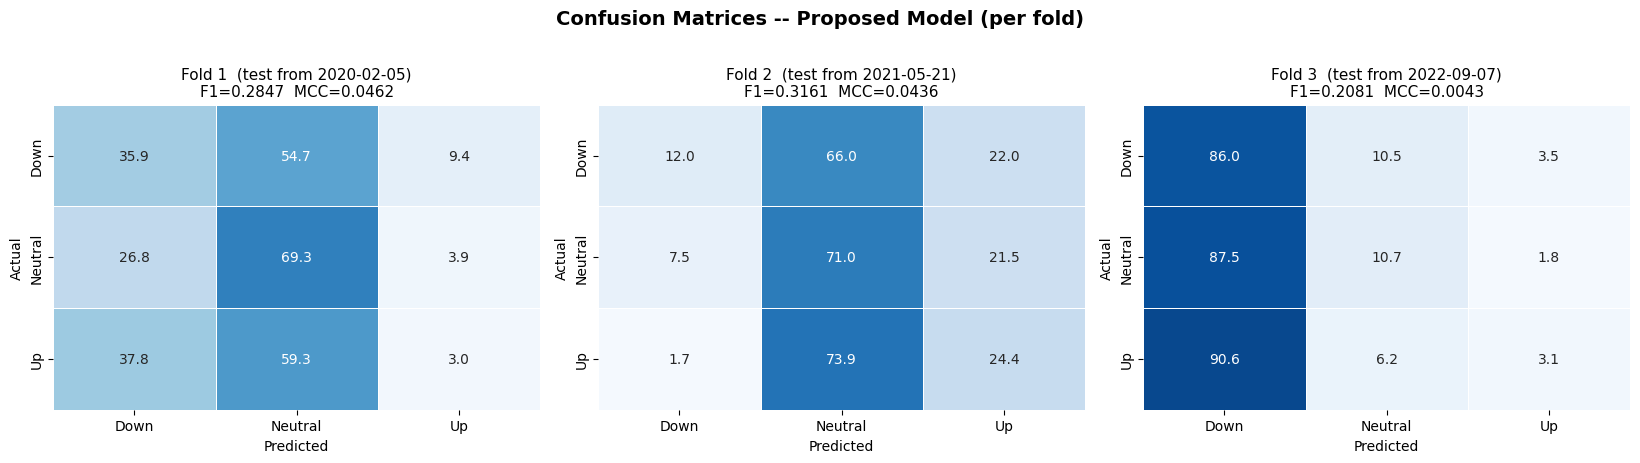

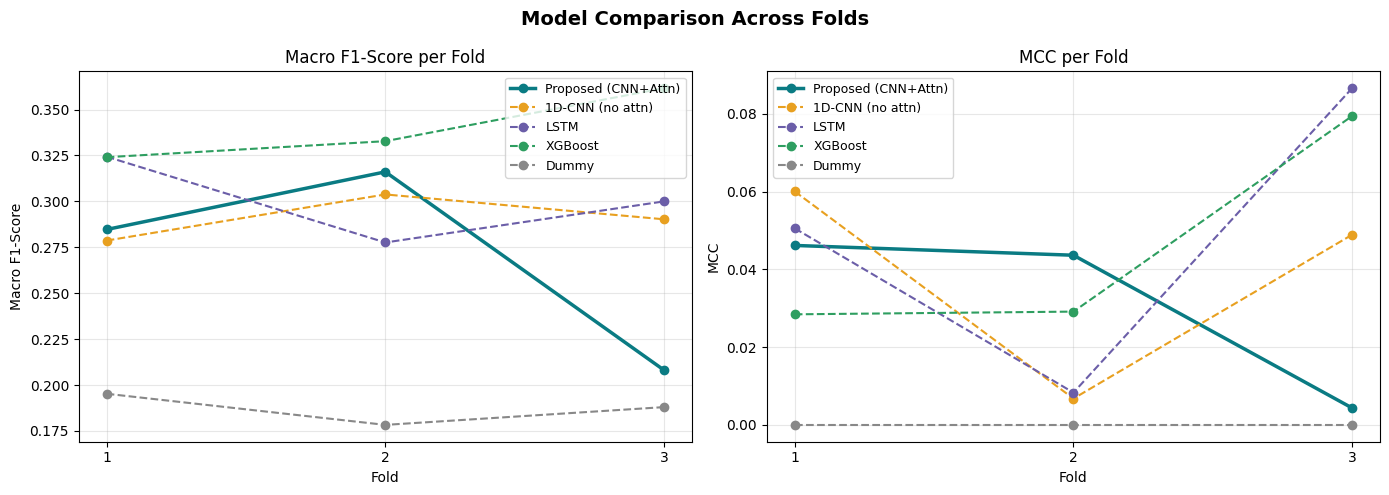

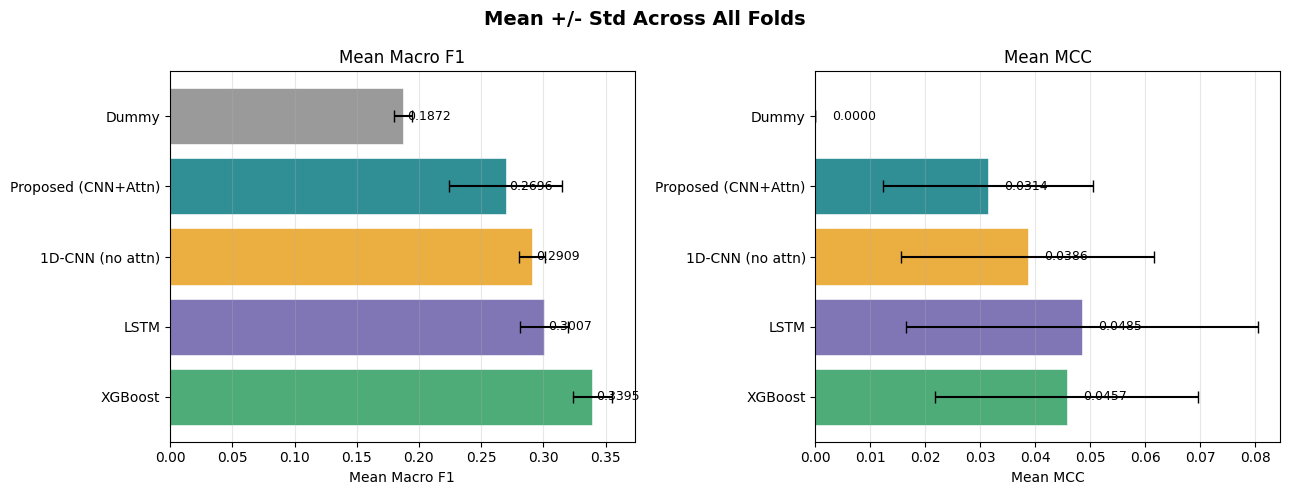

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — VISUALIZATIONS                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

CLASS_NAMES  = ['Down', 'Neutral', 'Up']
MODEL_COLORS = {
    'Proposed (CNN+Attn)': '#0A7B83',
    '1D-CNN (no attn)':    '#E8A020',
    'LSTM':                '#6B5EA8',
    'XGBoost':             '#2E9E60',
    'Dummy':               '#888888',
}

# Figure 1: Confusion matrices (Proposed model)
fig, axes = plt.subplots(1, N_FOLDS, figsize=(5.5 * N_FOLDS, 4.5))
if N_FOLDS == 1:
    axes = [axes]
fig.suptitle('Confusion Matrices -- Proposed Model (per fold)',
             fontsize=14, fontweight='bold', y=1.02)
for i, fold in enumerate(FOLDS):
    res = ALL_RESULTS['Proposed (CNN+Attn)'][i]
    cm  = res['conf_matrix']
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = cm.astype(float) / np.where(row_sums == 0, 1, row_sums) * 100
    ax = axes[i]
    sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=ax, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar=False, linewidths=0.5, vmin=0, vmax=100)
    te = pd.Timestamp(FOLDS[i]['dates_test'][0]).date()
    ax.set_title(f'Fold {fold["fold_id"]}  (test from {te})\n'
                 f'F1={res["macro_f1"]:.4f}  MCC={res["mcc"]:.4f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: F1 + MCC per fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison Across Folds', fontsize=14, fontweight='bold')
for metric_key, metric_label, ax in [
    ('macro_f1', 'Macro F1-Score', axes[0]),
    ('mcc',      'MCC',            axes[1])
]:
    for model_name, fold_results in ALL_RESULTS.items():
        vals  = [r[metric_key] for r in fold_results]
        folds = [r['fold_id']  for r in fold_results]
        lw = 2.5 if 'Proposed' in model_name else 1.5
        ls = '-'  if 'Proposed' in model_name else '--'
        ax.plot(folds, vals, marker='o', linewidth=lw, linestyle=ls,
                label=model_name, color=MODEL_COLORS.get(model_name, 'grey'))
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} per Fold')
    ax.set_xticks(range(1, N_FOLDS + 1))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: Summary bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Mean +/- Std Across All Folds', fontsize=14, fontweight='bold')
sorted_names = [r['Model'] for r in summary_rows]
colors       = [MODEL_COLORS.get(n, 'grey') for n in sorted_names]
for metric_key, std_key, metric_label, ax in [
    ('Mean F1',  'Std F1',  'Mean Macro F1', axes[0]),
    ('Mean MCC', 'Std MCC', 'Mean MCC',      axes[1]),
]:
    means = [next(r[metric_key] for r in summary_rows if r['Model'] == n)
             for n in sorted_names]
    stds  = [next(r[std_key]    for r in summary_rows if r['Model'] == n)
             for n in sorted_names]
    bars  = ax.barh(sorted_names, means, xerr=stds,
                    color=colors, alpha=0.85, capsize=4,
                    edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, means):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel(metric_label)
    ax.set_title(metric_label)
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('summary_bars.png', dpi=150, bbox_inches='tight')
plt.show()


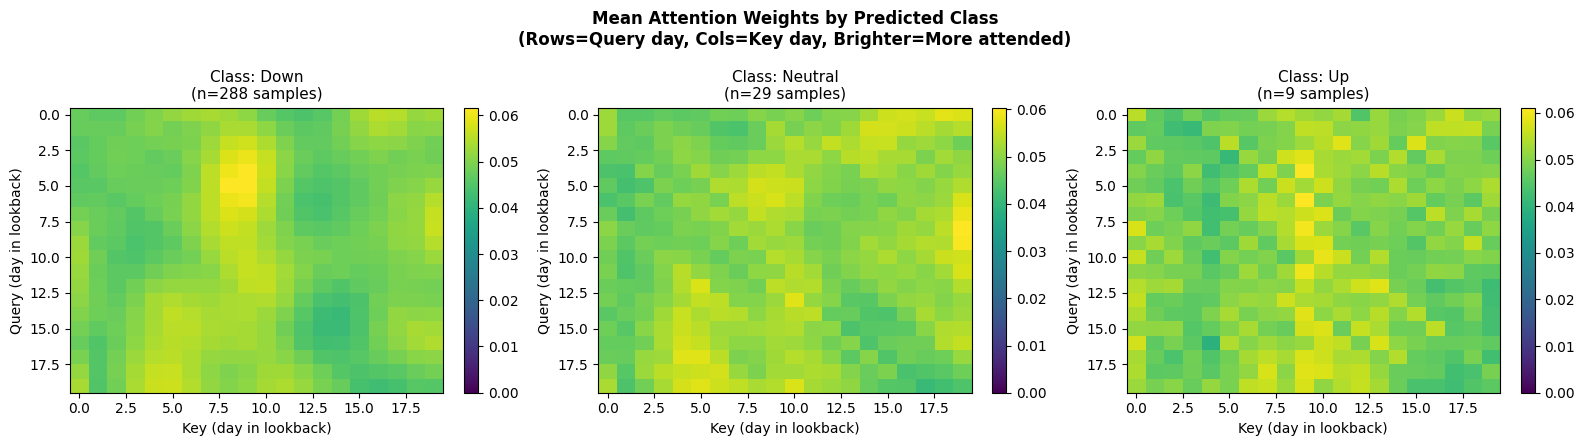

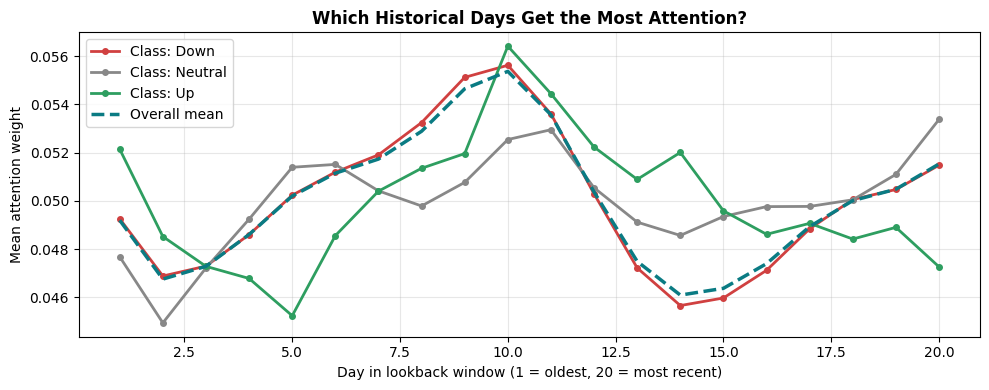


Attention interpretation guide:
  Peak at days 1-7  -> model attends to older regime signals
  Peak at days 14-20 -> momentum-driven, recency bias
  Different class patterns -> attention is regime-discriminative
  Uniform pattern -> attention adds global context only
  (All outcomes are scientifically valid -- report honestly)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — ATTENTION WEIGHT VISUALIZATION                       ║
# ╚══════════════════════════════════════════════════════════════════╝

CLASS_NAMES_VIZ = ['Down', 'Neutral', 'Up']
last_fold    = FOLDS[-1]
trained_prop = last_fold.get('trained_proposed')

if trained_prop is None:
    print('No trained proposed model found. Run Cell 8 first.')
else:
    trained_prop.eval()
    X_te     = torch.tensor(last_fold['X_test']).to(DEVICE)
    y_pred_l = ALL_RESULTS['Proposed (CNN+Attn)'][-1]['y_pred']

    with torch.no_grad():
        _ = trained_prop(X_te, return_attn=True)
    attn_all = trained_prop._attn_weights   # (N_test, T, T)

    if attn_all is None:
        print('Attention weights not captured.')
    else:
        # Plot 1: Mean attention heatmap by class
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        fig.suptitle(
            'Mean Attention Weights by Predicted Class\n'
            '(Rows=Query day, Cols=Key day, Brighter=More attended)',
            fontsize=12, fontweight='bold'
        )
        for cls_idx, cls_name in enumerate(CLASS_NAMES_VIZ):
            mask = y_pred_l == cls_idx
            ax   = axes[cls_idx]
            if mask.sum() == 0:
                ax.set_title(f'{cls_name}\n(no samples)')
                continue
            mean_attn = attn_all[mask].mean(axis=0)
            im = ax.imshow(mean_attn, cmap='viridis', aspect='auto', vmin=0)
            ax.set_title(f'Class: {cls_name}\n(n={mask.sum()} samples)', fontsize=11)
            ax.set_xlabel('Key (day in lookback)')
            ax.set_ylabel('Query (day in lookback)')
            plt.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout()
        plt.savefig('attention_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Plot 2: Per-class mean attention per time step
        fig, ax = plt.subplots(figsize=(10, 4))
        CLASS_COLORS = ['#D04040', '#888888', '#2E9E60']
        for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES_VIZ, CLASS_COLORS)):
            mask = y_pred_l == cls_idx
            if mask.sum() == 0:
                continue
            cls_attn = attn_all[mask].mean(axis=(0, 1))
            ax.plot(range(1, LOOKBACK + 1), cls_attn,
                    label=f'Class: {cls_name}', color=col,
                    linewidth=2, marker='o', markersize=4)
        overall = attn_all.mean(axis=(0, 1))
        ax.plot(range(1, LOOKBACK + 1), overall,
                label='Overall mean', color='#0A7B83',
                linewidth=2.5, linestyle='--')
        ax.set_xlabel('Day in lookback window (1 = oldest, 20 = most recent)')
        ax.set_ylabel('Mean attention weight')
        ax.set_title('Which Historical Days Get the Most Attention?', fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('attention_by_day.png', dpi=150, bbox_inches='tight')
        plt.show()

        print('\nAttention interpretation guide:')
        print('  Peak at days 1-7  -> model attends to older regime signals')
        print('  Peak at days 14-20 -> momentum-driven, recency bias')
        print('  Different class patterns -> attention is regime-discriminative')
        print('  Uniform pattern -> attention adds global context only')
        print('  (All outcomes are scientifically valid -- report honestly)')


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — SAVE RESULTS TO GOOGLE DRIVE (OPTIONAL)             ║
# ╚══════════════════════════════════════════════════════════════════╝

SAVE_TO_DRIVE = False   # set True to enable

if SAVE_TO_DRIVE:
    from google.colab import drive
    import shutil, os
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/ML_Project_Results'
    os.makedirs(OUT, exist_ok=True)
    df_results = pd.DataFrame(summary_rows)
    df_results.to_csv(f'{OUT}/results_summary.csv', index=False)
    for fname in ['confusion_matrices.png', 'fold_comparison.png',
                  'summary_bars.png', 'attention_heatmap.png',
                  'attention_by_day.png']:
        src = f'/content/{fname}'
        if os.path.exists(src):
            shutil.copy(src, f'{OUT}/{fname}')
            print(f'  Saved: {fname}')
    print(f'All results saved to {OUT}')
else:
    print('SAVE_TO_DRIVE = False')
    print('Files in /content/ -> right-click -> Download in the Files panel.')
